# Prac 02
For this homework you will have to complete and implement the colour balancing for:
* Gray world algorithm
* Scale-by-max algorithm

You are free to use your own images. Experiment with more images and think about the effect each of the algorithms has on the resulting (balanced) image.

### Colour Balancing
In this notebook we will show different type of colour balancing making use of von Kries' hypothesis.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 5]

(np.float64(-0.5), np.float64(641.5), np.float64(349.5), np.float64(-0.5))

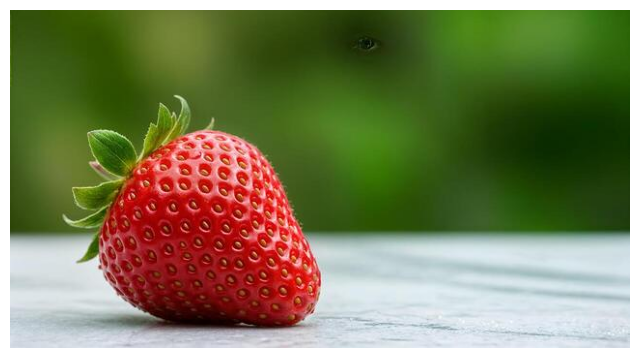

In [2]:
img = cv2.imread('../data/strawberry.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')

### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

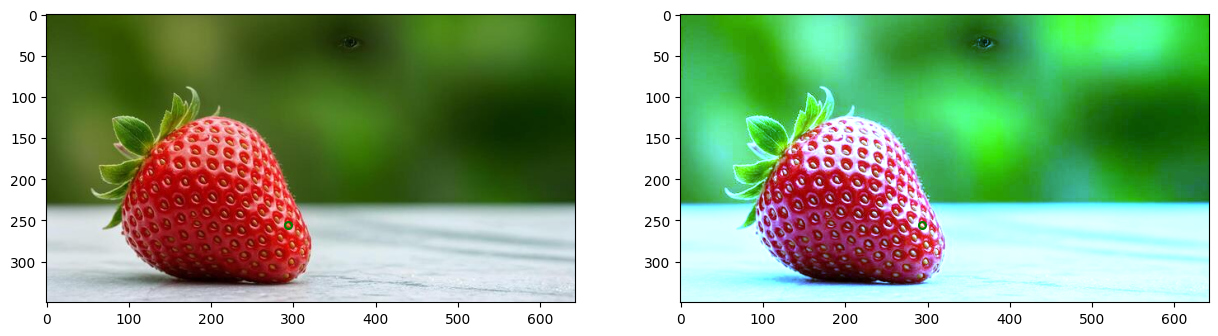

In [3]:
# Define white patch and the coefficients
img = cv2.imread('../data/strawberry.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

row, col = 256, 293
white = img[row, col, :]
coeffs = 255.0 / white

# Apply white balancing and generate balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for channel in range(3):
    balanced[..., channel] = img[..., channel] * coeffs[channel]

# White patching does not guarantee that the dynamic range is preserved, images must be clipped.
balanced = balanced / 255
balanced[balanced > 1] = 1

plt.subplot(121), plt.imshow(img)
plt.plot(col, row, 'o', markersize=5, markerfacecolor='none', markeredgecolor='green', markeredgewidth=1.5)
plt.subplot(122), plt.imshow(balanced)
plt.plot(col, row, 'o', markersize=5, markerfacecolor='none', markeredgecolor='green', markeredgewidth=1.5)

### Gray world
This algorithm assumes that a scene, on average, is gray.

(<Axes: >, <matplotlib.image.AxesImage at 0x1fba2b870d0>)

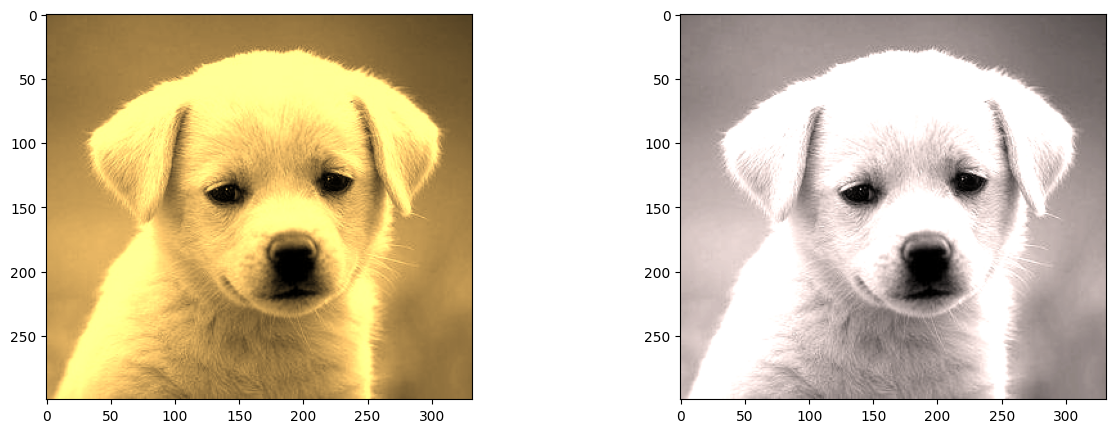

In [4]:
# Load your image
img = cv2.imread('../data/grey_dog_cast.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the mean values for all three colour channels (red, green, blue)
mean_r = np.mean(img[..., 0])
mean_g = np.mean(img[..., 1])
mean_b = np.mean(img[..., 2])

# Fix the brightest channel's coefficient to 1, compute the remaining two
max_mean = max(mean_r, mean_g, mean_b)
kr = max_mean / mean_r
kg = max_mean / mean_g
kb = max_mean / mean_b

# Apply color balancing and generate the balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for i, k in enumerate([kr, kg, kb]):
    balanced[..., i] = img[..., i] * k
balanced = np.clip(balanced, 0, 255).astype(np.uint8)

# Show the original and the balanced image side by side
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

(<Axes: >, <matplotlib.image.AxesImage at 0x1fba2c4dd50>)

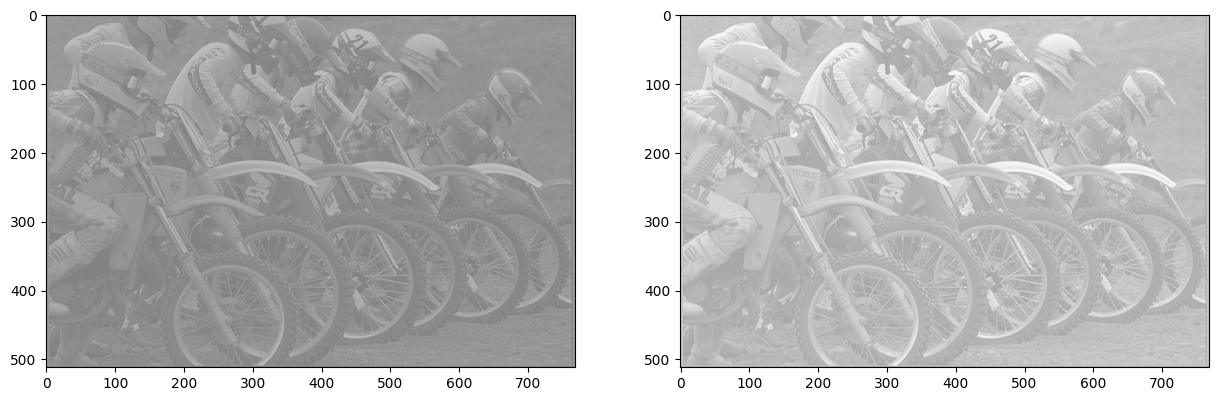

In [5]:
# Load your image
img = cv2.imread('../data/kodim05.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the maximum values for all three colour channels (red, green, blue)
max_r = np.max(img[..., 0])
max_g = np.max(img[..., 1])
max_b = np.max(img[..., 2])

# Apply scale-by-max balancing and generate the balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for i, mx in enumerate([max_r, max_g, max_b]):
    balanced[..., i] = img[..., i] * (255.0 / mx)
balanced = np.clip(balanced, 0, 255).astype(np.uint8)

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)